# 长尾训练

In [ ]:
! tensorboard --logdir=E:\Github\LT-Uncertainty\output\results\test\log

^C


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets, models
import os

# 定义一些超参数
batch_size = 32
test_path = r'D:\BaiduNetdiskDownload\Remote_Sense_Datasets\HRSC\test'    # 替换为你的测试集路径
image_size=512
crop_size=448

# 1. 数据预处理
test_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.CenterCrop((crop_size, crop_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

# 2. 加载数据集
test_dataset = datasets.ImageFolder(root=test_path, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. 加载预训练的ResNet18模型
model = models.resnet18(pretrained=False)
num_classes = len(test_dataset.classes)  # 计算类别数量
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 加载保存的模型权重
model_path = './output/models/HRSC/resnet18_model.pth'
model.load_state_dict(torch.load(model_path))

# 4. 使用GPU（如果有）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 5. 评估模型
model.eval()  # 设置模型为评估模式
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        print(labels,outputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0') tensor([[ 2.4079,  2.5240,  0.1894, -1.4025,  0.1344, -1.5008, -1.9083, -2.6482,
         -2.3984, -1.9938, -0.0610,  2.3360,  1.9878, -1.5222,  1.3376, -3.7216,
          0.9235, -1.5519],
        [ 2.6451,  2.8950, -0.5970, -0.2247, -1.0453, -1.3816, -1.4437, -1.6232,
         -3.1166, -2.5303, -0.1128,  1.8593,  2.8133, -2.0336,  0.9203, -2.4397,
          0.4120, -2.5795],
        [ 2.6648,  3.0190, -0.4162, -0.5554, -0.6341, -1.5849, -1.8170, -2.0850,
         -3.0432, -2.4390, -0.3896,  1.9938,  2.9449, -1.8507,  1.2109, -2.8342,
          0.6680, -2.4363],
        [-0.1205,  3.4635, -0.0854, -0.5067, -2.5944,  0.9683, -1.3625,  2.0842,
         -0.0914, -3.6837, -1.0264,  3.1508,  2.0298, -1.8270, -2.2840, -1.5314,
         -1.8436, -2.3513],
        [-0.5817,  3.5910,  0.1884, -0.9750, -2.9048,  0.7831, -1.0697,  1.6858,
          0.0567, -3.3420, -0

# 伽马函数单调性

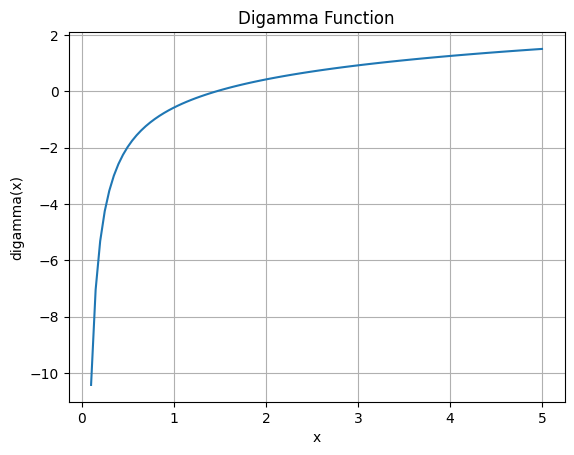

In [1]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(0.1, 5, 100)
y = torch.digamma(x)

plt.plot(x.numpy(), y.numpy())
plt.title("Digamma Function")
plt.xlabel("x")
plt.ylabel("digamma(x)")
plt.grid(True)
plt.show()


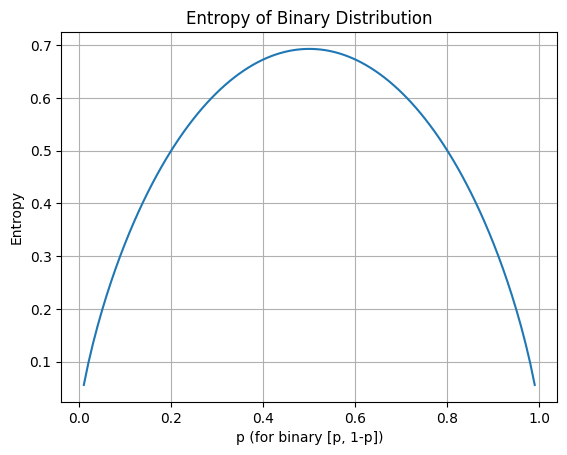

In [2]:
import torch
import matplotlib.pyplot as plt

def entropy(p):
    return -torch.sum(p * torch.log(p + 1e-10), dim=-1)

x = torch.linspace(0.01, 0.99, 100)
entropy_vals = entropy(torch.stack([x, 1 - x], dim=1))

plt.plot(x.numpy(), entropy_vals.numpy())
plt.xlabel('p (for binary [p, 1-p])')
plt.ylabel('Entropy')
plt.title('Entropy of Binary Distribution')
plt.grid(True)
plt.show()


# 分析不确定性的变化

## K/S和EU的关系

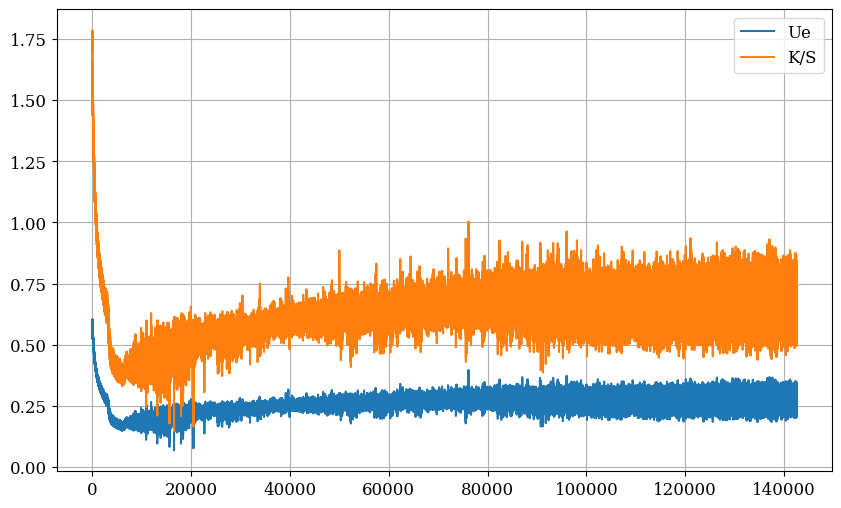

           loss        Up        Ue        Ua       K/S     label         N
loss   1.000000  0.192410  0.875616 -0.205984  0.851899  0.204770 -0.208471
Up     0.192410  1.000000  0.048296  0.856671 -0.032351  0.122753 -0.103789
Ue     0.875616  0.048296  1.000000 -0.380213  0.994726  0.078510 -0.014905
Ua    -0.205984  0.856671 -0.380213  1.000000 -0.453884  0.100241 -0.073803
K/S    0.851899 -0.032351  0.994726 -0.453884  1.000000  0.065189 -0.008987
label  0.204770  0.122753  0.078510  0.100241  0.065189  1.000000 -0.231702
N     -0.208471 -0.103789 -0.014905 -0.073803 -0.008987 -0.231702  1.000000


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取数据
# file_path = r'E:\Github\LT-Uncertainty\output\FGSC\_reset50\trust_decomposition_warmup+cosine\results\loss.txt'  # 替换成你的实际路径
file_path = r'E:\Github\LT-Uncertainty\output\FGSC\_resnet50\v2\trust_smooth_warmup+cosine7-31-sig3-2-a0-sm0.2\results\loss.txt'
df = pd.read_csv(file_path, sep=' ', header=None)
df.columns = ['loss', 'Up', 'Ue','Ua', 'K/S','label']
DataLabel2num = {12: 434, 0: 387, 9: 274, 17: 236, 19: 234, 2: 190, 5: 180, 1: 132, 10: 132, 21: 123, 4: 114, 8: 96, 16: 86, 11: 82, 6: 81, 14: 74, 18: 72, 22: 71, 13: 70, 20: 70, 7: 58, 15: 43, 3: 17}
df['N'] = df['label'].map(DataLabel2num)
plot_columns = ['K/S','Ue']
df['Ua'] = df['Up'] - df['Ue']
# 2. 绘制折线图
# 设置中文字体为 SimHei，支持负号
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use SimHei for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display issue
plt.figure(figsize=(10, 6))
for col in df.columns:
    if col in plot_columns:
        plt.plot(df.index, df[col], label=col)

# plt.xlabel('样本编号')
# plt.ylabel('数值')
# plt.title('每列数据的折线图')
plt.legend()
plt.grid(True)
# plt.tight_layout()
plt.show()
correlation_matrix = df.corr(method='spearman')
print(correlation_matrix)

In [29]:
df

,loss,Up,Ue,Ua,K/S,label,N
0,105.805023,3.068130,0.524440,2.543689,1.439845,1,132
1,79.531975,3.068053,0.529736,2.538317,1.459003,21,123
2,85.193634,3.070520,0.535239,2.535281,1.476381,16,86
3,97.903450,3.067809,0.540906,2.526903,1.498956,10,132
4,94.301834,3.066011,0.541974,2.524037,1.504092,2,190
...,...,...,...,...,...,...,...
138008,7.447049,2.948398,0.283726,2.664672,0.687678,19,234
138009,14.530711,3.083573,0.326319,2.757255,0.794021,12,434
138010,3.216175,2.559360,0.244522,2.314838,0.602802,21,123
138011,2.021551,2.359083,0.212815,2.146268,0.520569,8,96


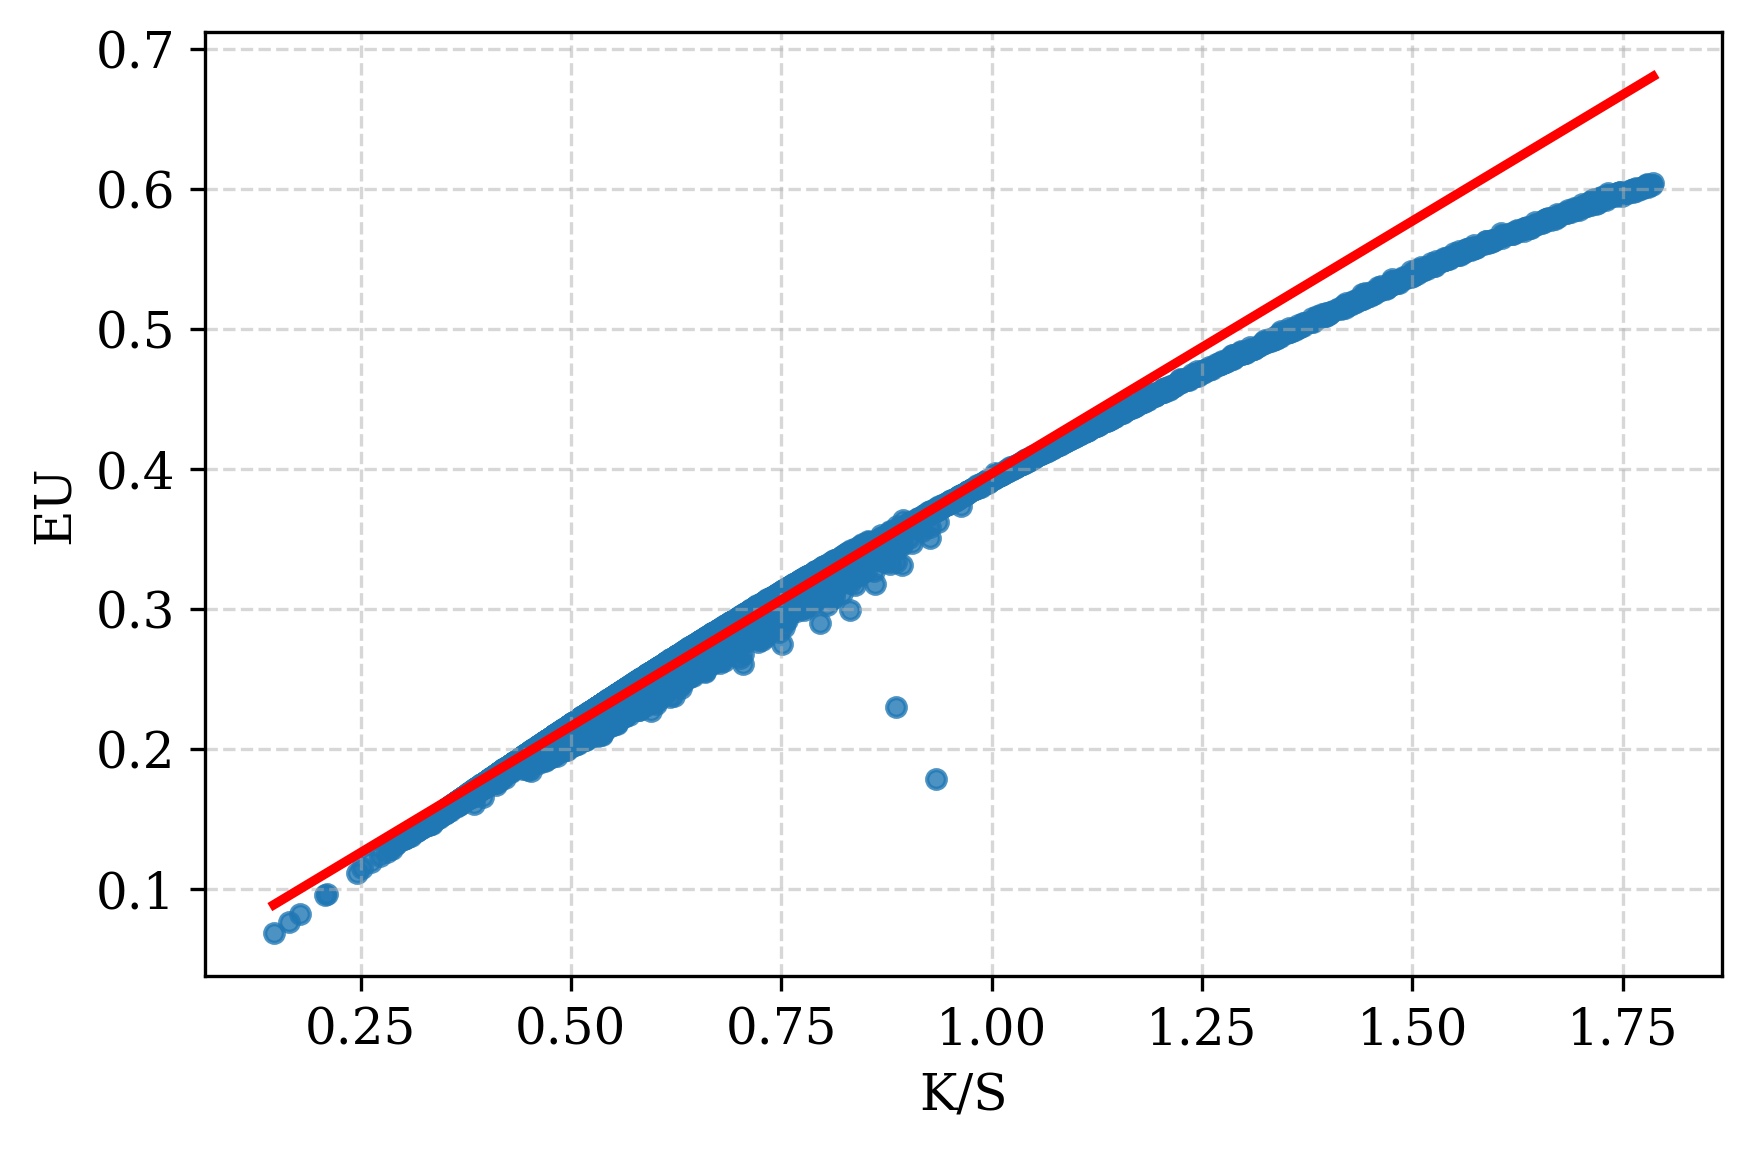

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置论文风格（Latex 字体 + 尺寸）
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12

plt.figure(figsize=(6, 4), dpi=300)
sns.regplot(x='K/S', y='Ue', data=df, scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.xlabel('K/S')
plt.ylabel('EU')
# plt.title('Relationship between A and B')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig('./figure/correlation_plot.png', dpi=600)
plt.show()


## 类别数量和不确定性的关系
需要记录label，batch 1
label、count、Ue、Ua、loss、K/S
resnet50/18 FGSC 100 30min

# 分析Evalution

In [31]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 

In [35]:
train_result = r"E:\Github\LT-Uncertainty\output\FGSC\_resnet50\v2\trust_decomposition_warmup+cosine7-31-sig1-1-a0\results\train_results.csv"
test_result = r"E:\Github\LT-Uncertainty\output\FGSC\_resnet50\v2\trust_decomposition_warmup+cosine7-31-sig1-1-a0\results\test_results.csv"
df_train = pd.read_csv(train_result)
df_test = pd.read_csv(test_result)

In [36]:
import pandas as pd

def summarize_by_label(df):
    # 分组聚合
    grouped = df.groupby('label').agg(
        count=('label', 'count'),
        accuracy=('correct', lambda x: x.sum() / len(x)),
        mean_Up=('Up', 'mean'),
        mean_Ue=('Ue', 'mean'),
        mean_Ua=('Ua', 'mean'),
        mean_Ks=('K/s', 'mean')
    ).reset_index()

    return grouped

# 假设 df 已经加载
summary_train = summarize_by_label(df_train)
summary_test = summarize_by_label(df_test)
print(summary_train)


    label  count  accuracy   mean_Up   mean_Ue   mean_Ua   mean_Ks
0       0    387  0.844961  2.759892  0.295696  2.464196  0.732272
1       1    132  0.651515  2.935280  0.326725  2.608555  0.807270
2       2    190  0.500000  3.084929  0.350474  2.734455  0.860726
3       3     17  0.058824  3.095090  0.347803  2.747286  0.852375
4       4    114  0.745614  3.005602  0.334791  2.670811  0.824941
5       5    180  0.438889  3.074598  0.347164  2.727434  0.852773
6       6     81  0.395062  3.068339  0.338770  2.729569  0.832086
7       7     58  0.465517  3.084493  0.354711  2.729782  0.873325
8       8     96  0.854167  2.895810  0.288956  2.606854  0.713345
9       9    274  0.518248  3.061426  0.334616  2.726810  0.821912
10     10    132  0.212121  3.069248  0.323654  2.745594  0.794619
11     11     82  0.085366  3.074824  0.349391  2.725433  0.858184
12     12    434  0.875576  2.975592  0.329615  2.645977  0.812443
13     13     70  0.242857  3.077890  0.346324  2.731565  0.85

In [38]:
summary_train.corr(method='spearman')

,label,count,accuracy,mean_Up,mean_Ue,mean_Ua,mean_Ks
label,1.000000,-0.221453,-0.450050,0.487154,0.497036,0.384387,0.528656
count,-0.221453,1.000000,0.584364,-0.541275,-0.508156,-0.535838,-0.472566
accuracy,-0.450050,0.584364,1.000000,-0.866469,-0.723047,-0.872404,-0.711177
mean_Up,0.487154,-0.541275,-0.866469,1.000000,0.926877,0.893281,0.913043
mean_Ue,0.497036,-0.508156,-0.723047,0.926877,1.000000,0.699605,0.996047
mean_Ua,0.384387,-0.535838,-0.872404,0.893281,0.699605,1.000000,0.671937
mean_Ks,0.528656,-0.472566,-0.711177,0.913043,0.996047,0.671937,1.000000


In [37]:
# 只保留数值列进行相关性分析
# summar = summary_train
# summar['test_acc'] = summary_test['accuracy']
epoch = 4
b = 102
correlation_matrix = df_test.iloc[b*epoch:b*(epoch+1)].corr(method='spearman')
print(correlation_matrix)
epoch+=1


            label      pred   correct        Up        Ue        Ua       K/s
label    1.000000  0.745198  0.764903 -0.433577 -0.325614 -0.556558 -0.310392
pred     0.745198  1.000000  0.575657 -0.304476 -0.256441 -0.354986 -0.248059
correct  0.764903  0.575657  1.000000 -0.612293 -0.513925 -0.684564 -0.498534
Up      -0.433577 -0.304476 -0.612293  1.000000  0.961923  0.906328  0.952378
Ue      -0.325614 -0.256441 -0.513925  0.961923  1.000000  0.787211  0.998609
Ua      -0.556558 -0.354986 -0.684564  0.906328  0.787211  1.000000  0.773516
K/s     -0.310392 -0.248059 -0.498534  0.952378  0.998609  0.773516  1.000000


In [ ]:
a = []
epoch = 0
b = 102
while(b*(epoch+1)<=df.shape[0]):
    correlation_matrix = df.iloc[b*epoch:b*(epoch+1)].corr(method='spearman')
    a.append(correlation_matrix['Ue']['count'])
    epoch += 1
plt.figure()
plt.scatter(range(len(a)),a)
plt.show()

In [311]:
from scipy.stats import pearsonr,spearmanr

r, p = spearmanr(summar['mean_Ue'], summar['count'])
print(f"相关系数 r: {r:.2f}, p值: {p:.4f}")


相关系数 r: -0.67, p值: 0.0005


In [309]:
summar

,label,count,accuracy,mean_Up,mean_Ue,mean_Ua,mean_Ks,test_acc
0,0,387,0.997416,2.131750,0.207128,1.924622,0.515668,0.804124
1,1,132,1.000000,2.281358,0.227599,2.053759,0.566750,0.852941
2,2,190,1.000000,2.173029,0.210557,1.962472,0.524113,0.812500
3,3,17,1.000000,2.932954,0.332843,2.600112,0.826214,0.900000
4,4,114,0.991228,2.510248,0.263028,2.247220,0.655044,0.862069
5,5,180,1.000000,2.643070,0.287682,2.355388,0.717997,0.755556
6,6,81,0.987654,2.573408,0.271827,2.301581,0.676334,0.578947
7,7,58,1.000000,2.731542,0.297398,2.434143,0.740251,0.857143
8,8,96,1.000000,2.315056,0.228861,2.086195,0.569017,0.958333
9,9,274,0.992701,2.553456,0.270251,2.283205,0.673552,0.652174


# ACC格式化
从output中提取头尾类的正确率

In [2]:
# 获取对应数据的dict
def get_class2label(dataset_name:str):
    if dataset_name == 'dota':
        DataLabel2num = {14: 28068, 2: 26126, 11: 16969, 12: 7971, 9: 5983, 4: 5029, 6: 2367, 7: 2047, 5: 1736, 10: 630, 1: 515, 0: 415, 13: 399, 3: 326, 8: 325}
        class2label={
            "Baseball-diamond": 0,
            "Basketball-court": 1,
            "Bridge": 2,
            "Ground-track-field": 3,
            "Harbor": 4,
            "Helicopter": 5,
            "Large-Vehicle": 6,
            "Plane": 7,
            "Roundabout": 8,
            "Ship": 9,
            "Small-Vehicle": 10,
            "Soccer-ball-field": 11,
            "Swimming-Pool": 13,
            "Storage-Tank": 12,
            "Tennis-court": 14,
            }
        return DataLabel2num
    
    elif dataset_name == 'dior':
        DataLabel2num = {5: 27290, 10: 13713, 8: 4906, 7: 3053, 12: 2384, 3: 2369, 11: 2365, 0: 1892, 14: 1363, 4: 1336, 2: 1150, 17: 1080, 13: 1076, 1: 661, 15: 649, 18: 610, 6: 595, 16: 512, 19: 511, 9: 502}
        class2label={
            "Ship": 13,
            "Vehicle": 18,
            "Tennis court": 16,
            "Storage tank": 15,
            "Baseball field": 2,
            "Harbor": 11,
            "Windmill": 19,
            "Airplane": 0,
            "Bridge": 4,
            "Overpass": 12,
            "Ground track field": 10,
            "Expressway-Service area": 7,
            "Basketballcourt": 3,
            "Airport": 1,
            "Chimney": 5,
            "Expressway-toll-station": 8,
            "Stadium": 14,
            "Dam": 6,
            "Golf field": 9,
            "Train station": 17
            }
        return DataLabel2num
    
    elif dataset_name == 'fgsc23':
        real_label_to_data_label = {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '3': 16, '4': 17, '5': 18, '6': 19, '7': 20, '8': 21, '9': 22}
        DataLabel2num = {12: 434, 0: 387, 9: 274, 17: 236, 19: 234, 2: 190, 5: 180, 1: 132, 10: 132, 21: 123, 4: 114, 8: 96, 16: 86, 11: 82, 6: 81, 14: 74, 18: 72, 22: 71, 13: 70, 20: 70, 7: 58, 15: 43, 3: 17}

        label2class={
            0:"non-ship",
            1:"air carrier",
            2:"destroyer",
            3:"landing craft",
            4:"frigate",
            5:"amphibious transport dock",
            6:"cruiser",
            7:"Tarawa-class amphibious assault ship",
            8:"amphibious assault ship",
            9:"command ship",
            10:"submarine",
            11:"medical ship",
            12:"combat boat",
            13:"auxiliary ship",
            14:"container ship",
            15:"car carrier",
            16:"hovercraft",
            17:"bulk carrier",
            18:"oil tanker",
            19:"fishing boat",
            20:"passenger ship",
            21:"liquefied gas ship",
            22:"barge"}
        class2label = {value: key for key, value in label2class.items()}
        return DataLabel2num
    else:
        raise ValueError(f"input dataset_name error: {dataset_name}")

In [3]:
DataLabel2num = get_class2label(dataset_name='fgsc23')
fgsc23_sorted_dict = dict(sorted(DataLabel2num.items(), key=lambda item: item[1], reverse=True))
DataLabel2num = get_class2label(dataset_name='dior')
dior_sorted_dict = dict(sorted(DataLabel2num.items(), key=lambda item: item[1], reverse=True))
DataLabel2num = get_class2label(dataset_name='dota')
dota_sorted_dict = dict(sorted(DataLabel2num.items(), key=lambda item: item[1], reverse=True))

In [4]:
import re
import pandas as pd
import numpy as np
def head_tail_AvgAcc(flie_path, n, sorted_dict):
    all_epochs_class_accuracy = []

    current_epoch = None
    current_class_accuracy = {}

    with open(flie_path, 'r') as f:
        for line in f:
            line = line.strip()

            # 提取 Epoch 编号
            
            epoch_match = re.match(r'Epoch (\d+)', line)
            if epoch_match:
                if current_epoch is not None and current_class_accuracy:
                    all_epochs_class_accuracy.append((current_epoch, current_class_accuracy))
                    current_class_accuracy = {}
                current_epoch = int(epoch_match.group(1))

            # 提取 Class Accuracy
            class_match = re.match(r'Class (\d+) Accuracy: ([\d.]+)%', line)
            if class_match:
                class_id = int(class_match.group(1))
                accuracy = float(class_match.group(2))
                current_class_accuracy[class_id] = accuracy

        # 加入最后一个 Epoch 的数据
        if current_epoch is not None and current_class_accuracy:
            all_epochs_class_accuracy.append((current_epoch, current_class_accuracy))

    # 转换为 DataFrame
    df = pd.DataFrame(
        [{**{'Epoch': epoch}, **acc_dict} for epoch, acc_dict in all_epochs_class_accuracy]
    )

    # 设置 Epoch 为索引（可选）
    df.set_index('Epoch', inplace=True)
    acc_list = df.iloc[-1].to_list()
    data = dict()
    for dl,_ in sorted_dict.items():
        data[dl] = acc_list[dl]
    # 打印label：Acc
    print(data)
    # n = 7  # 前 n 个
    values = [v for i, (k, v) in enumerate(data.items())]
    head_avg = sum(values[:n])/n
    tail_avg = sum(values[n:])/(len(values)-n)
    print(values[:n])
    print(values[n:])
    return head_avg, tail_avg

In [11]:
# fgsc
flie_path = r"E:\Github\LT-Uncertainty\output\FGSC\_resnet50\v2\trust_smooth_warmup+cosine7-21-sig3-2-a0\results\results.txt"
head_avg, tail_avg = head_tail_AvgAcc(flie_path,7,fgsc23_sorted_dict)
print(head_avg, tail_avg)

{12: 84.26, 0: 81.44, 9: 59.42, 17: 91.53, 19: 83.05, 2: 83.33, 5: 64.44, 1: 82.35, 10: 60.61, 21: 80.65, 4: 89.66, 8: 95.83, 16: 90.91, 11: 70.0, 6: 78.95, 14: 100.0, 18: 77.78, 22: 77.78, 13: 55.56, 20: 77.78, 7: 85.71, 15: 100.0, 3: 100.0}
[84.26, 81.44, 59.42, 91.53, 83.05, 83.33, 64.44]
[82.35, 60.61, 80.65, 89.66, 95.83, 90.91, 70.0, 78.95, 100.0, 77.78, 77.78, 55.56, 77.78, 85.71, 100.0, 100.0]
78.21000000000001 82.723125


In [16]:
# dior
flie_path = r"E:\Github\LT-Uncertainty\output\dior\pretrained_reset50\v2\trust_smooth_warmup+cosine7-12\results\results.txt"
head_avg, tail_avg = head_tail_AvgAcc(flie_path,8,dior_sorted_dict)
print(head_avg, tail_avg)

{5: 90.59, 10: 96.76, 8: 94.48, 7: 91.44, 12: 92.66, 3: 80.96, 11: 98.8, 0: 78.7, 14: 72.39, 4: 79.7, 2: 96.17, 17: 94.65, 13: 96.46, 1: 96.85, 15: 83.53, 18: 79.22, 6: 82.02, 16: 79.14, 19: 97.22, 9: 92.34}
[90.59, 96.76, 94.48, 91.44, 92.66, 80.96, 98.8, 78.7]
[72.39, 79.7, 96.17, 94.65, 96.46, 96.85, 83.53, 79.22, 82.02, 79.14, 97.22, 92.34]
90.54875000000001 87.47416666666665


In [87]:
# dota
flie_path = r"E:\Github\LT-Uncertainty\output\DOTA\pretrained_reset50\v2\trust_smooth_warmup+cosine7-12\results\results.txt"
head_avg, tail_avg = head_tail_AvgAcc(flie_path,6,dota_sorted_dict)
print(head_avg, tail_avg)

{14: 97.86, 2: 96.4, 11: 95.44, 12: 98.74, 9: 96.27, 4: 98.1, 6: 95.79, 7: 91.38, 5: 91.14, 10: 73.97, 1: 87.88, 0: 95.33, 13: 83.24, 3: 90.2, 8: 93.75}
[97.86, 96.4, 95.44, 98.74, 96.27, 98.1]
[95.79, 91.38, 91.14, 73.97, 87.88, 95.33, 83.24, 90.2, 93.75]
97.13499999999999 89.18666666666667


## Other SOTA 

In [7]:
def print_SOTA_result(a, n):
    s = sum(a[:n])
    print(a[:n])
    head_avg = s/n 
    s = sum(a[n:])
    print(a[n:])
    tail_avg =  s/(len(a)-n)
    print(f"head:{head_avg}, tail:{tail_avg}")

In [8]:
# TGN FGSC
a = [83.33, 70.10, 55.07, 84.75, 79.66, 75.00, 57.78, 82.35, 48.48, 64.52, 79.31, 87.50, 59.09, 45.00, 50.00, 100, 61.11, 66.67, 66.67, 55.56, 85.71, 90.91, 60.00]
print_SOTA_result(a, 7)

[83.33, 70.1, 55.07, 84.75, 79.66, 75.0, 57.78]
[82.35, 48.48, 64.52, 79.31, 87.5, 59.09, 45.0, 50.0, 100, 61.11, 66.67, 66.67, 55.56, 85.71, 90.91, 60.0]
head:72.24142857142856, tail:68.93


In [10]:
# TGN DOTA
a = [98.14, 98.22, 87.05, 97.65, 95.41, 96.92, 98.63, 95.55, 81.11, 92.98, 82.61, 41.18, 72.32, 78.57, 90.48]
print_SOTA_result(a, 6)

[98.14, 98.22, 87.05, 97.65, 95.41, 96.92]
[98.63, 95.55, 81.11, 92.98, 82.61, 41.18, 72.32, 78.57, 90.48]
head:95.565, tail:81.49222222222222


In [11]:
# TGN DIOR
a = [90.68, 90.19, 96.98, 94.73, 90.28, 93.97, 78.82, 98.90, 83.99, 71.16, 72.67, 94.31, 92.81, 94.28, 93.84, 82.95, 72.97, 80.68, 74.12, 96.70, 87.62]
print_SOTA_result(a, 8)

[90.68, 90.19, 96.98, 94.73, 90.28, 93.97, 78.82, 98.9]
[83.99, 71.16, 72.67, 94.31, 92.81, 94.28, 93.84, 82.95, 72.97, 80.68, 74.12, 96.7, 87.62]
head:91.81875000000001, tail:84.46923076923078


In [16]:
# EME
S_head = 86.90*3+3*92.03
S_tail = 3*92.03+6*89.32
S_head/6, S_tail/9

(89.46500000000002, 90.22333333333333)

In [17]:
# T2TFS
S_head = 78.26*3+3*91.31
S_tail = 3*91.31+6*87.80
S_head/6, S_tail/9

(84.78500000000001, 88.97)